# Single-cell copy-number variation with CopyKAT

This tutorial walks through `ov.single.CNV(method='copykat')` — a thin
omicverse wrapper around the pure-Python
[py-CopyKAT](https://github.com/omicverse/py-CopyKAT) re-implementation of
the R CopyKAT method
([Gao et al., *Nature Biotechnology* 2021](https://doi.org/10.1038/s41587-020-00795-2)).

CopyKAT is **unsupervised**: it classifies each cell as `aneuploid`
(tumour) or `diploid` (normal) without needing a reference cell-type
annotation. The wrapper writes results to a unified schema shared with
inferCNV so the plotting helpers (`ov.pl.cnv_heatmap`, `ov.pl.cnv_summary`,
`ov.pl.cnv_umap`) work with either backend.


## Part.1 The math behind CopyKAT

CopyKAT runs an 11-step pipeline. The core ideas:

**1. Stabilise raw counts.** The variance-stabilising transform
$$\;\;y = \log(\sqrt{x} + \sqrt{x+1})$$
maps Poisson-distributed counts to a near-Gaussian scale, after which the
expression matrix is centred per cell.

**2. Local denoising.** A Kalman smoother sweeps along each chromosome to
suppress per-gene noise while preserving step changes at copy-number
breakpoints.

**3. Baseline estimation.** A Gaussian mixture (or the user-supplied
`norm_cell_names`) identifies the diploid baseline, which is subtracted
to give per-gene log-ratios.

**4. Segmentation.** A Poisson-gamma MCMC scheme detects breakpoints
shared across cells, then aggregates genes into ~220 kb bins.

**5. Classification.** A KS-test on the aggregated CN profile flags each
cell as $\mathrm{aneuploid}$ ($\Delta \mathrm{KS}\ge\tau$, default 0.1)
or $\mathrm{diploid}$. Aneuploid cells are then clustered by dynamic tree
cut to recover subclones.

Reference: [Gao et al., Nat Biotechnol (2021)](https://doi.org/10.1038/s41587-020-00795-2).


## Part.2 Load data

We use the Maynard et al. (2020) lung adenocarcinoma 3 000-cell scRNA-seq
benchmark. The file already carries gene-coordinate metadata in
`adata.var` (`chromosome`, `start`, `end`), which both CopyKAT and
inferCNV expect.


In [1]:
import omicverse as ov
ov.plot_set()


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import os
import scanpy as sc
import omicverse as ov

# Maynard et al. (2020) lung adenocarcinoma scRNA-seq — 3 000 cells, 55 556
# genes, gene coordinates already in adata.var. Bundled by infercnvpy.
DATA_URL = "https://github.com/icbi-lab/infercnvpy/releases/download/d0.1.0/maynard2020_3k.h5ad"
data_dir = "data/cnv"
os.makedirs(data_dir, exist_ok=True)
adata = sc.read(f"{data_dir}/maynard2020_3k.h5ad", backup_url=DATA_URL)
adata


  0%|          | 0.00/49.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 3000 × 55556
    obs: 'age', 'sex', 'sample', 'patient', 'cell_type'
    var: 'ensg', 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_counts', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'cell_type_colors', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    obsp: 'connectivities', 'distances'

In [3]:
# Quick look at cell-type composition. Epithelial cells are the
# candidate tumour population; immune/stromal cells (Macrophage, T cell,
# Fibroblast, ...) act as the diploid majority CopyKAT needs to anchor
# the baseline against.
adata.obs["cell_type"].value_counts().head(10)


cell_type
Epithelial cell     522
Macrophage          409
Fibroblast          308
T cell CD4          259
T cell CD8          246
Monocyte            227
Endothelial cell    148
Plasma cell         139
other               115
mDC                 106
Name: count, dtype: int64

## Part.3 Run CopyKAT

`ov.single.CNV(method='copykat')` consumes raw counts directly. For the
3 000-cell input it finishes in ~1-2 minutes on CPU (`pycopykat` is a
Numba-accelerated port; no R / no GPU required).

After `cnv.run()`:

| slot | content |
|---|---|
| `adata.obsm['X_cnv']`         | cells × ~12 k 220 kb bins of log-CN |
| `adata.uns['cnv']['chr_pos']` | chromosome → starting-bin index |
| `adata.obs['cnv_prediction']` | `'aneuploid'` / `'diploid'` / NaN |
| `adata.obs['cnv_score']`      | per-cell mean abs(log-CN) |


In [4]:
cnv = ov.single.CNV(adata, method='copykat', genome='hg20')
cnv.run(verbose=False)


In [5]:
adata.obs["cnv_prediction"].value_counts(dropna=False)


cnv_prediction
diploid      2561
aneuploid     412
NaN            27
Name: count, dtype: int64

## Part.4 Genome-wide heatmap

`ov.pl.cnv_heatmap` plots every cell as one row, ordered by `groupby` —
in this case the CopyKAT classification — across the ordered genomic
bins. Gain = red, loss = blue, with an alternating chromosome ideogram
across the top. The aneuploid (tumour) band should show clear, recurrent
gains and losses while the diploid (normal) band stays near zero.


(<Figure size 640x400 with 3 Axes>,
 {'heatmap': <Axes: xlabel='Ordered genomic positions', ylabel='3,000 cells'>,
  'ideogram': <Axes: >,
  'cbar': <Axes: ylabel='CN (log ratio)'>})

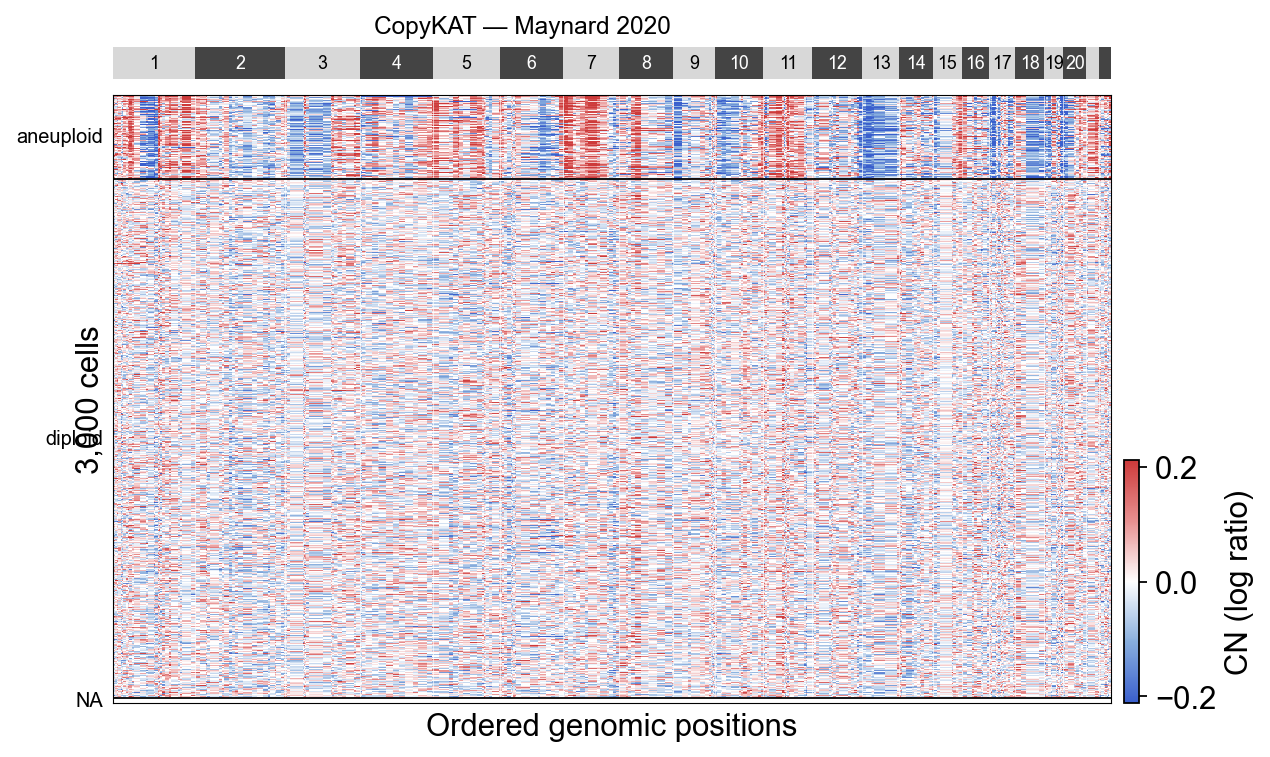

In [6]:
ov.pl.cnv_heatmap(adata, groupby='cnv_prediction',
                  figsize=(8, 5), title='CopyKAT — Maynard 2020')


## Part.5 Mean CN summary

`ov.pl.cnv_summary` reduces the heatmap to a single line: the mean log-CN
across cells (or a subset) per genomic bin. Filling above zero
(`gain_color`) and below zero (`loss_color`) makes copy-number gain /
loss regions instantly visible. Below we plot the aneuploid mean — this
is the de-facto pseudo-bulk CNV profile of the tumour.


(<Figure size 640x208 with 2 Axes>,
 {'line': <Axes: xlabel='Ordered genomic positions', ylabel='Mean CN (log ratio)'>,
  'ideogram': <Axes: >})

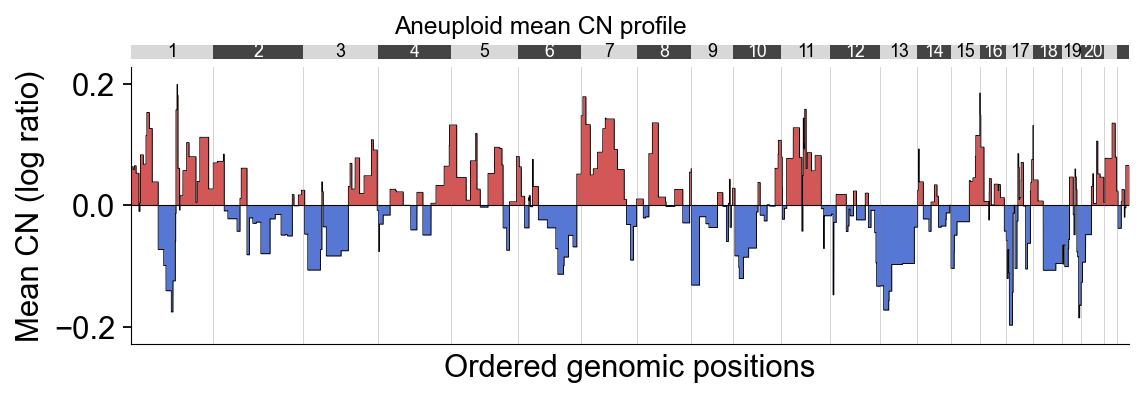

In [7]:
ov.pl.cnv_summary(adata, groupby='cnv_prediction', subset='aneuploid',
                  figsize=(8, 2.6), title='Aneuploid mean CN profile')


## Part.6 UMAP

The dataset already has a UMAP in `adata.obsm['X_umap']`.
`ov.pl.cnv_umap` colours it by the two columns CopyKAT writes —
`cnv_prediction` (categorical) and `cnv_score` (continuous). The
aneuploid cells should fall into one or a few coherent clusters that
overlap with the original Epithelial-cell annotation.


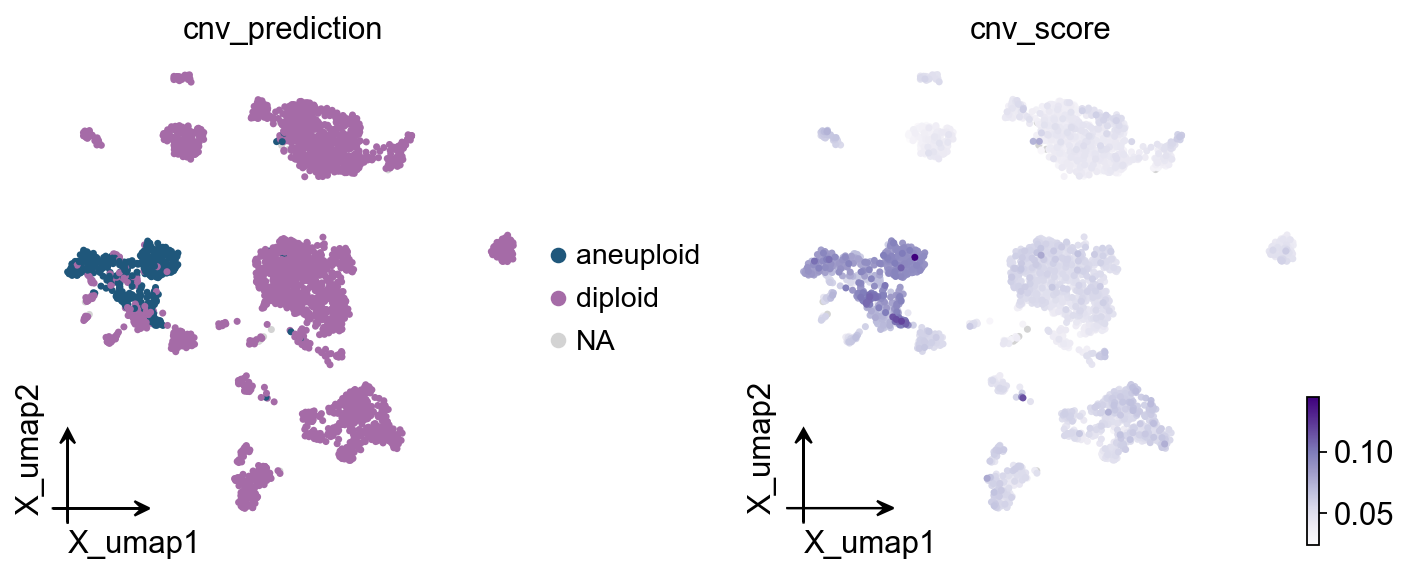

In [8]:
ov.pl.cnv_umap(adata)


---

**Next steps:** for reference-anchored CNV inference (when you have a
clean normal-cell annotation), see the
[inferCNV tutorial](t_infercnv.ipynb). For an in-depth comparison
between CopyKAT and inferCNV on the same dataset, run both methods
end-to-end and visualise their `cnv_score` columns side-by-side with
`ov.pl.embedding(adata, color=['cnv_score_copykat', 'cnv_score_infercnv'])`.
